In [1]:
"""Resolve project root dynamically for portable imports and data paths."""
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "utility.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "utility.py").exists():
    raise RuntimeError("Could not locate project root containing utility.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"


In [2]:
import pandas as pd
import utility

##### read fixed mutation data

In [3]:
fixed_mutation_sheet = pd.read_excel(str(DATA_DIR / "fixed_mutation.xlsx"), sheet_name="Sheet1")
fixed_mutation_sheet


,CHROM,Position,REF,ALT,refrence allele,up stream,down stram,file_name,QUAL,SVTYPE,...,LOH_fixed_by_10150,present_at_10150,ID,mutation_group,group_mutation_type,group_mutation_impact,in_telomere,ref_flank,alt_flank,population_name
0,2-micron,141,C,T,C,GCGAGACAAA,AGGACAATTA,NaN,23994.97,NaN,...,0.0,1,2-micron_141_T,1,noncoding,NaN,0,GCGAGACAAACAGGACAATTA,GCGAGACAAATAGGACAATTA,P3C07
1,2-micron,2576,T,C,T,GTGACCTTTG,ATTGACAAAT,NaN,22083.79,NaN,...,1.0,1,2-micron_2576_C,2,missense,MODERATE,0,GTGACCTTTGTATTGACAAAT,GTGACCTTTGCATTGACAAAT,P3C07
2,2-micron,2986,G,A,G,CTTAATACAA,CAAGCAGTCT,NaN,24140.52,NaN,...,1.0,1,2-micron_2986_A,3,missense,MODERATE,0,CTTAATACAAGCAAGCAGTCT,CTTAATACAAACAAGCAGTCT,P3C07
3,2-micron,3082,T,C,T,TACAGAAGGT,TTCGCGGTTT,NaN,25546.51,NaN,...,1.0,1,2-micron_3082_C,4,noncoding,MODIFIER,0,TACAGAAGGTTTTCGCGGTTT,TACAGAAGGTCTTCGCGGTTT,P3C07
4,2-micron,4525,G,A,G,CGCATACTTT,TGAACAGAAA,NaN,21905.18,NaN,...,1.0,1,2-micron_4525_A,6,noncoding,NaN,0,CGCATACTTTGTGAACAGAAA,CGCATACTTTATGAACAGAAA,P3C07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25694,chrXVI,851553,A,T,A,GTATATGTTG,GCAAGTGTGT,NaN,386.35,NaN,...,1.0,1,chrXVI_851553_T,200,missense,MODERATE,0,GTATATGTTGAGCAAGTGTGT,GTATATGTTGTGCAAGTGTGT,P2F09
25695,chrXVI,867714,G,A,G,TTGTCTTCGT,GTCGAATCTA,NaN,506.66,NaN,...,0.0,1,chrXVI_867714_A,201,synonymous,LOW,0,TTGTCTTCGTGGTCGAATCTA,TTGTCTTCGTAGTCGAATCTA,P2F09
25696,chrXVI,898887,C,A,C,GGCCTATGAC,CGCTGGAACA,NaN,1715.24,NaN,...,0.0,1,chrXVI_898887_A,202,missense,MODERATE,0,GGCCTATGACCCGCTGGAACA,GGCCTATGACACGCTGGAACA,P2F09
25697,chrXVI,941276,G,T,G,AAATGGGTTT,TTCACGCCAT,NaN,831.57,NaN,...,0.0,1,chrXVI_941276_T,203,noncoding,NaN,0,AAATGGGTTTGTTCACGCCAT,AAATGGGTTTTTTCACGCCAT,P2F09


In [4]:
# fixed_mutation_sheet.drop_duplicates()

##### read gain sheet

In [5]:
def _read_yeast_metadata():
    """Load precomputed yeast evolved-genome metadata CSV; fail fast if missing."""
    candidate_paths = [
        Path("yeast_evolved_genome_metadata.csv"),
        PROJECT_ROOT / "figure" / "main" / "fig6" / "yeast_evolved_genome_metadata.csv",
        PROJECT_ROOT / "figure" / "Supplementary" / "fig6" / "yeast_evolved_genome_metadata.csv",
        DATA_DIR / "yeast_evolved_genome_metadata.csv",
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            return pd.read_csv(candidate)

    searched = "\n".join(f"- {p}" for p in candidate_paths)
    raise FileNotFoundError(
        "Missing required input: yeast_evolved_genome_metadata.csv\n"
        "Searched:\n"
        f"{searched}\n\n"
        "Generate this file by running figure/main/fig6/evolved_genome_yeast_fasta.ipynb "
        "(the cell that writes df_full.to_csv('yeast_evolved_genome_metadata.csv', index=False))."
    )

ag_sheet = _read_yeast_metadata()
ag_sheet


,Position,CHROM,REF,ALT,population_name,G70_ref_counts,G1410_ref_counts,G2640_ref_counts,G5150_ref_counts,G7530_ref_counts,G10150_ref_counts,G70_alt_counts,G1410_alt_counts,G2640_alt_counts,G5150_alt_counts,G7530_alt_counts,G10150_alt_counts,accumulate_gain,kGain_evolved_genome
0,31,chrVIII,C,A,P3G06,35,31,59,38,42,56,0,0,0,0,11,0,-3.577119,-3.577119
1,34,2-micron,G,T,P1E04,74,104,3,0,0,1,0,217,426,323,156,236,0.392871,0.392871
2,34,chrII,G,A,P2C06,4,0,1,0,2,1,0,0,0,0,16,12,-4.563850,-4.311335
3,36,chrIX,C,A,P2F11,24,5,39,2,34,2,0,0,0,0,5,0,-11.012777,-11.012777
4,36,chrIX,C,A,P3F11,44,1,38,4,18,2,0,0,0,0,9,0,-11.012777,-11.012777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133529,1525964,chrIV,C,T,P3G10,0,0,0,1,2,0,3,5,12,7,18,0,8.835324,8.835324
133530,1525964,chrIV,C,T,P3G11,2,0,1,1,0,0,0,0,6,0,4,0,8.835324,8.835324
133531,1525998,chrIV,T,C,P3B07,0,0,1,1,3,0,2,0,0,1,8,0,-14.496006,-14.496006
133532,1525998,chrIV,T,C,P3B10,0,0,0,4,2,1,0,0,3,2,0,0,-14.496006,-14.719149


In [6]:
# ag_sheet.drop_duplicates()

In [7]:
# ag_sheet = pd.read_excel(str(DATA_DIR / 'fixed_mutation.xlsx'), sheet_name='Sheet2')
# ag_sheet

##### Merge gain and fixed count dataframes on common columns

In [8]:
merged_df = pd.merge(
    fixed_mutation_sheet,
    ag_sheet[['CHROM', 'Position', 'REF', 'ALT', 'population_name', 'accumulate_gain', 'kGain_evolved_genome']],
    on=['CHROM', 'Position', 'REF', 'ALT', 'population_name'],
    how='left',
    indicator=True,
    validate='many_to_one'
)

unmatched_rows = (merged_df['_merge'] != 'both').sum()
if unmatched_rows > 0:
    print(f"Warning: {unmatched_rows} rows have no kGain metadata match and will be excluded from plotting/stats.")

merged_df = merged_df.loc[merged_df['_merge'] == 'both'].drop(columns=['_merge']).copy()


In [9]:
merged_df

,CHROM,Position,REF,ALT,refrence allele,up stream,down stram,file_name,QUAL,SVTYPE,...,ID,mutation_group,group_mutation_type,group_mutation_impact,in_telomere,ref_flank,alt_flank,population_name,accumulate_gain,kGain_evolved_genome
0,2-micron,141,C,T,C,GCGAGACAAA,AGGACAATTA,NaN,23994.97,NaN,...,2-micron_141_T,1,noncoding,NaN,0,GCGAGACAAACAGGACAATTA,GCGAGACAAATAGGACAATTA,P3C07,0.460847,0.460847
1,2-micron,2576,T,C,T,GTGACCTTTG,ATTGACAAAT,NaN,22083.79,NaN,...,2-micron_2576_C,2,missense,MODERATE,0,GTGACCTTTGTATTGACAAAT,GTGACCTTTGCATTGACAAAT,P3C07,-2.585438,-2.585438
2,2-micron,2986,G,A,G,CTTAATACAA,CAAGCAGTCT,NaN,24140.52,NaN,...,2-micron_2986_A,3,missense,MODERATE,0,CTTAATACAAGCAAGCAGTCT,CTTAATACAAACAAGCAGTCT,P3C07,6.325886,6.325886
3,2-micron,3082,T,C,T,TACAGAAGGT,TTCGCGGTTT,NaN,25546.51,NaN,...,2-micron_3082_C,4,noncoding,MODIFIER,0,TACAGAAGGTTTTCGCGGTTT,TACAGAAGGTCTTCGCGGTTT,P3C07,-4.901611,-4.901611
4,2-micron,4525,G,A,G,CGCATACTTT,TGAACAGAAA,NaN,21905.18,NaN,...,2-micron_4525_A,6,noncoding,NaN,0,CGCATACTTTGTGAACAGAAA,CGCATACTTTATGAACAGAAA,P3C07,1.634026,1.634026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25694,chrXVI,851553,A,T,A,GTATATGTTG,GCAAGTGTGT,NaN,386.35,NaN,...,chrXVI_851553_T,200,missense,MODERATE,0,GTATATGTTGAGCAAGTGTGT,GTATATGTTGTGCAAGTGTGT,P2F09,-4.976722,-4.976722
25695,chrXVI,867714,G,A,G,TTGTCTTCGT,GTCGAATCTA,NaN,506.66,NaN,...,chrXVI_867714_A,201,synonymous,LOW,0,TTGTCTTCGTGGTCGAATCTA,TTGTCTTCGTAGTCGAATCTA,P2F09,2.969015,2.969015
25696,chrXVI,898887,C,A,C,GGCCTATGAC,CGCTGGAACA,NaN,1715.24,NaN,...,chrXVI_898887_A,202,missense,MODERATE,0,GGCCTATGACCCGCTGGAACA,GGCCTATGACACGCTGGAACA,P2F09,1.565519,1.565519
25697,chrXVI,941276,G,T,G,AAATGGGTTT,TTCACGCCAT,NaN,831.57,NaN,...,chrXVI_941276_T,203,noncoding,NaN,0,AAATGGGTTTGTTCACGCCAT,AAATGGGTTTTTTCACGCCAT,P2F09,5.688471,5.688471


##### Evolved kGain vs generation with fixation status as hue

Label=fixed_by_70, p_raw=1.73e-01, p_reported=1.73e-01, effect size=1.09e-01, 95% CI [-1.89e-01, 3.17e-01]
Label=fixed_by_1410, p_raw=5.32e-02, p_reported=6.39e-02, effect size=1.19e-01, 95% CI [3.10e-02, 1.89e-01]
Label=fixed_by_2640, p_raw=4.71e-03, p_reported=7.06e-03, effect size=9.49e-02, 95% CI [3.76e-02, 1.49e-01]
Label=fixed_by_5150, p_raw=3.25e-03, p_reported=6.50e-03, effect size=8.53e-02, 95% CI [3.53e-02, 1.35e-01]
Label=fixed_by_7530, p_raw=2.72e-03, p_reported=6.50e-03, effect size=6.00e-02, 95% CI [1.51e-02, 1.04e-01]
Label=fixed_by_10150, p_raw=1.03e-03, p_reported=6.19e-03, effect size=6.08e-02, 95% CI [8.41e-03, 1.06e-01]


,category,x_column,y_column,hue_column,group1_name,group2_name,n_group1,n_group2,test,alternative,effect_size_name,effect_size,ci_level,ci_low,ci_high,p_raw,p_adjust_method,p_adjusted
0,fixed_by_70,Mutation_Type,kGain_evolved_genome,Fixed,True,False,86,24676,Mann-Whitney U,greater,median_based_distance,0.108932,95,-0.188935,0.316545,0.172798,fdr_bh,0.172798
1,fixed_by_1410,Mutation_Type,kGain_evolved_genome,Fixed,True,False,1375,23416,Mann-Whitney U,greater,median_based_distance,0.118975,95,0.030968,0.189039,0.053228,fdr_bh,0.063874
2,fixed_by_2640,Mutation_Type,kGain_evolved_genome,Fixed,True,False,3955,20851,Mann-Whitney U,greater,median_based_distance,0.094927,95,0.037649,0.149123,0.004706,fdr_bh,0.007058
3,fixed_by_5150,Mutation_Type,kGain_evolved_genome,Fixed,True,False,7825,17018,Mann-Whitney U,greater,median_based_distance,0.085308,95,0.035283,0.135345,0.003248,fdr_bh,0.006496
4,fixed_by_7530,Mutation_Type,kGain_evolved_genome,Fixed,True,False,11400,13468,Mann-Whitney U,greater,median_based_distance,0.060048,95,0.015140,0.104311,0.002723,fdr_bh,0.006496
5,fixed_by_10150,Mutation_Type,kGain_evolved_genome,Fixed,True,False,15446,9427,Mann-Whitney U,greater,median_based_distance,0.060750,95,0.008415,0.105715,0.001032,fdr_bh,0.006193


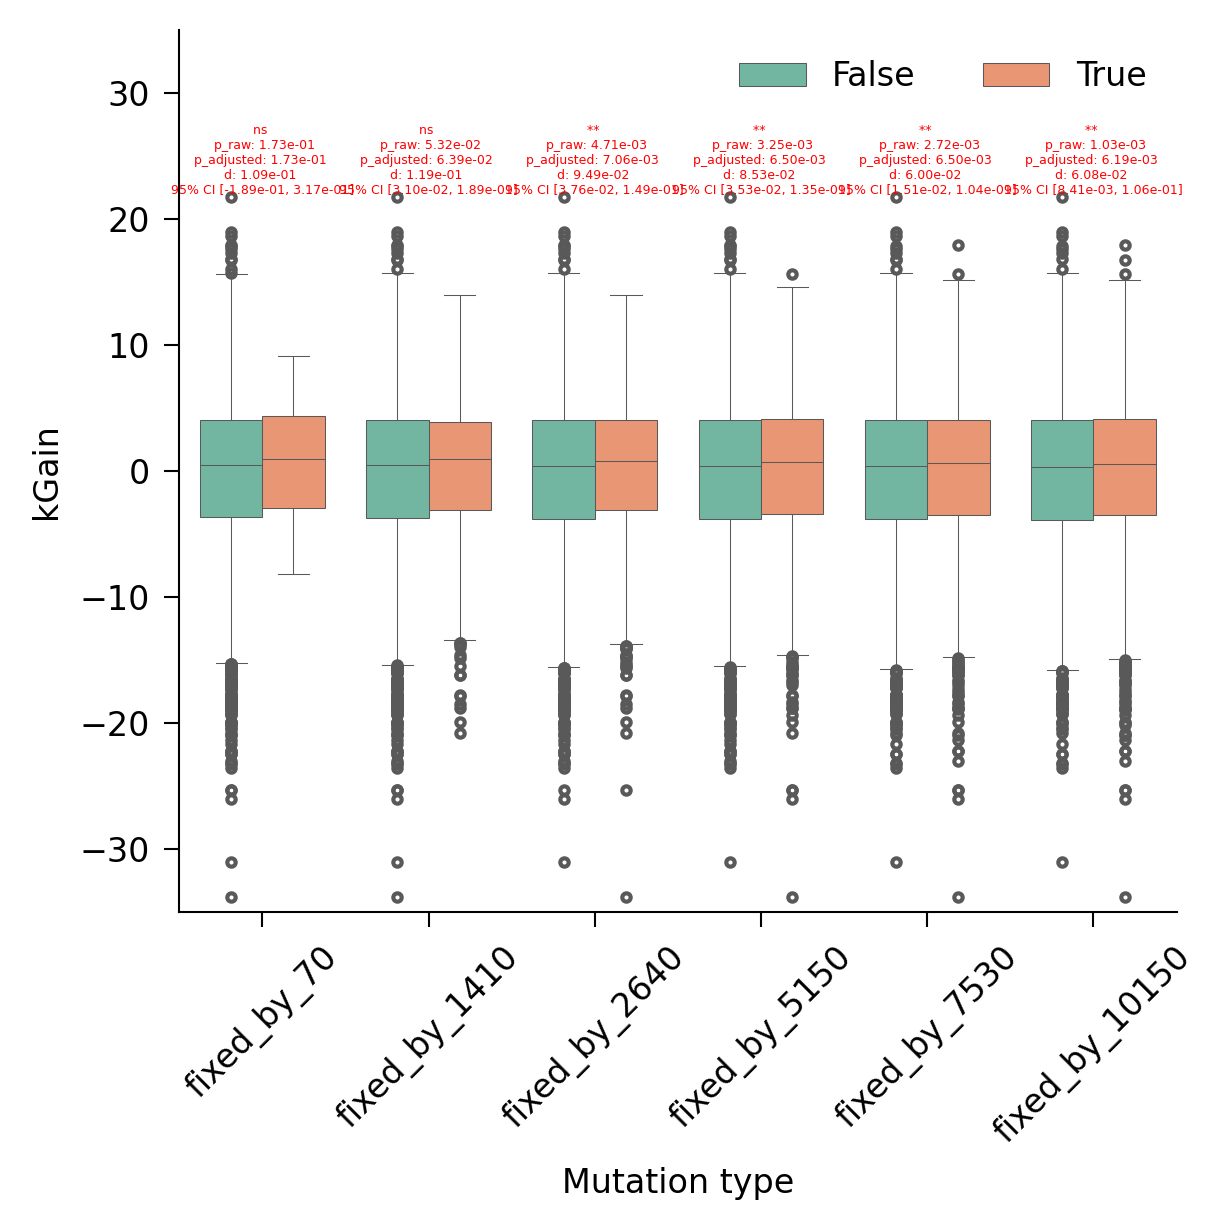

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

columns_for_box_plot = ['fixed_by_70', 'fixed_by_1410', 'fixed_by_2640', 'fixed_by_5150', 'fixed_by_7530', 'fixed_by_10150']
merged_df[columns_for_box_plot] = merged_df[columns_for_box_plot].astype(int)

df_melted = pd.melt(
    merged_df,
    id_vars=['kGain_evolved_genome'],
    value_vars=columns_for_box_plot,
    var_name='Mutation_Type',
    value_name='Fixed'
)

df_melted = df_melted.dropna(subset=['kGain_evolved_genome', 'Fixed']).copy()
df_melted['Fixed'] = df_melted['Fixed'].replace({0: 'False', 1: 'True'})

df_melted  = df_melted.drop_duplicates()

df_melted['generation_number'] = (
    df_melted['Mutation_Type']
    .str.extract(r'_(\d+)$')[0]
    .astype('Int64')
)
mutation_order = (
    df_melted[['Mutation_Type', 'generation_number']]
    .drop_duplicates()
    .sort_values('generation_number')['Mutation_Type']
    .tolist()
)

fig, ax = plt.subplots(1, 1, figsize=(4.2, 4.2), dpi=300)

data = df_melted.copy()
x_column = 'Mutation_Type'
y_column = 'kGain_evolved_genome'
hue_column = 'Fixed'
group1_name = 'True'
group2_name = 'False'

ax = sns.boxplot(
    data=data,
    x=x_column,
    y=y_column,
    hue=hue_column,
    order=mutation_order,
    fliersize=2,
    linewidth=0.25,
    width=0.75,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'black',
        'markeredgecolor': 'black',
        'markersize': '5'
    },
    palette='Set2',
    dodge=True
)

ax = utility.return_box_with_p_effect_size(
    ax=ax,
    data=data,
    x_columns=x_column,
    y_columns=y_column,
    group1_name=group1_name,
    group2_name=group2_name,
    y_pos=22,
    fontsize=3,
    hue_columns=hue_column,
    p_adjust_method='fdr_bh',
    alternative='greater'
)

ax.set_ylabel('kGain')
ax.set_xlabel('Mutation type')
ax = utility.custom_figure_axis(ax, fontsize=8, rotation=45)
ax.legend(ncol=2, frameon=False, fontsize=8)
ax.tick_params(axis='x', which='both', labelsize=8, bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', labelsize=8, left=True, right=False, direction='out')
ax.set_ylim(-35, 35)

plt.tight_layout()
plt.savefig('fig7c_kgain_fixed_status_boxplot.pdf', dpi=300)

fig7c_stats = utility.summarize_boxplot_pairwise_stats(
    data=data,
    x_columns=x_column,
    y_columns=y_column,
    group1_name=group1_name,
    group2_name=group2_name,
    hue_columns=hue_column,
    p_adjust_method='fdr_bh',
    alternative='greater',
)
fig7c_stats.to_csv('fig7c_stats_summary.csv', index=False)
fig7c_stats
